# 模型建立流程（改善版）- Boy or Girl 2025

## 本版本改善項目
1. **資料洩漏修正** — LabelEncoder 改為只 fit 在訓練集，OrdinalEncoder 處理未知類別
2. **self_intro 文字特徵強化** — 新增 8 個文字特徵（字數、詞數、大小寫比例、標點、首字大寫等）
3. **修正 VotingEnsemble refitting 問題** — 傳入未訓練的 estimator 物件，統一由 VotingClassifier 管理
4. **新增 CatBoost 模型** — 原生支援類別特徵，不需 label encoding
5. **新增 Stacking Ensemble** — 以 XGB + LGB + RF + CatBoost 為 base，Logistic Regression 為 meta-learner
6. **sleepiness / yt 異常值標記** — 補齊原本遺漏的欄位

In [61]:
import os, re, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, VotingClassifier,
                              StackingClassifier)
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, roc_curve, auc,
                             classification_report)
from sklearn.base import BaseEstimator, TransformerMixin

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed: pip install xgboost")

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("LightGBM not installed: pip install lightgbm")

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except ImportError:
    HAS_CAT = False
    print("CatBoost not installed: pip install catboost")

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DATA_DIR = Path('./data')
TRAIN_PATH = DATA_DIR / 'boy or girl 2025 train_missingValue.csv'
TEST_PATH  = DATA_DIR / 'boy or girl 2025 test no ans_missingValue.csv'

if TRAIN_PATH.exists() and TEST_PATH.exists():
    df_train = pd.read_csv(TRAIN_PATH)
    df_test  = pd.read_csv(TEST_PATH)
    print(f"Train shape: {df_train.shape}")
    print(f"Test  shape: {df_test.shape}")
else:
    raise FileNotFoundError(f"找不到資料檔案，請確認路徑:\n{TRAIN_PATH}\n{TEST_PATH}")


Train shape: (423, 11)
Test  shape: (426, 11)


## 1. 資料探索 (EDA)

In [62]:
print("=" * 70)
print("基本概覽")
print("=" * 70)
print(df_train.head())
print()
print("目標變數分布:")
print(df_train['gender'].value_counts())
ratio = df_train['gender'].value_counts()
print(f"不平衡比例: {ratio[1]}:{ratio[2]} = {ratio[1]/ratio[2]:.2f}:1")

print()
print("遺失值統計:")
miss = df_train.isnull().sum()
miss_pct = miss / len(df_train) * 100
print(pd.DataFrame({'count': miss, 'pct%': miss_pct.round(1)})[miss > 0])


基本概覽
   id  gender star_sign phone_os  height  weight  sleepiness     iq  \
0   1       2       處女座    Apple   154.0    43.0         NaN    NaN   
1   2       2       處女座    Apple   156.0    47.0         NaN  130.0   
2   3       1       射手座      NaN   170.0    61.0         NaN   90.0   
3   4       1       射手座    Apple   170.0    62.0         4.0  100.0   
4   5       2       射手座  Android   158.0    67.0         NaN  128.0   

   fb_friends   yt                     self_intro  
0       583.0    0                      Beautiful  
1         NaN  3.5  Enjoying being who I'm notsss  
2       540.0  NaN         Practice Makes perfect  
3         NaN    5                Straightforward  
4       320.0  1.2                       Humorous  

目標變數分布:
gender
1    316
2    107
Name: count, dtype: int64
不平衡比例: 316:107 = 2.95:1

遺失值統計:
            count  pct%
star_sign      86  20.3
phone_os       78  18.4
height         74  17.5
weight         85  20.1
sleepiness     91  21.5
iq             79  1

## 2. 特徵工程

### 改善重點
- **self_intro 文字特徵強化**：新增 8 個特徵捕捉書寫風格
- **補齊 sleepiness / yt 異常值標記**
- **yt 欄位型別修正**（原始資料為字串，需轉為 float）
- 所有轉換邏輯封裝於 `FeatureEngineer`，fit 只使用訓練集

In [63]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    特徵工程轉換器。
    fit() 不學習任何統計量（所有規則為硬規則），
    因此 fit_transform(X_train) 與 transform(X_test) 行為一致，
    不存在資料洩漏風險。
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # ── A. 型別修正 ─────────────────────────────────────────────────
        num_cols = ['height', 'weight', 'sleepiness', 'iq', 'fb_friends', 'yt']
        for col in num_cols:
            X[col] = pd.to_numeric(X[col], errors='coerce')

        # ── B. 遺失值 indicator（先做，避免後續 NaN 覆蓋混淆） ──────────
        miss_cols = ['height', 'weight', 'sleepiness', 'iq',
                     'fb_friends', 'yt', 'star_sign', 'phone_os', 'self_intro']
        for col in miss_cols:
            X[f'{col}_is_missing'] = X[col].isnull().astype(int)

        # ── C. 異常值 indicator（補齊 sleepiness / yt） ─────────────────
        X['height_is_anomaly']     = ((X['height'] < 140) | (X['height'] > 200)).astype(int)
        X['weight_is_anomaly']     = ((X['weight'] < 35)  | (X['weight'] > 120)).astype(int)
        X['iq_is_anomaly']         = ((X['iq'] < 50)      | (X['iq'] > 180)).astype(int)
        X['fb_friends_is_anomaly'] = (X['fb_friends'] > 5000).astype(int)
        X['sleepiness_is_anomaly'] = ((X['sleepiness'] < 0) | (X['sleepiness'] > 24)).astype(int)
        X['yt_is_anomaly']         = (X['yt'] > 24).astype(int)

        # ── D. 極端值轉 NaN（避免破壞梯度） ────────────────────────────
        X.loc[(X['height'] > 250) | (X['height'] < 100), 'height'] = np.nan
        X.loc[(X['weight'] > 200) | (X['weight'] < 20),  'weight'] = np.nan
        X.loc[X['yt'] > 24, 'yt'] = np.nan

        # ── E. 基礎衍生特徵 ─────────────────────────────────────────────
        h_m = X['height'] / 100
        X['bmi'] = (X['weight'] / (h_m ** 2)).replace([np.inf, -np.inf], np.nan)

        X['social_activity'] = (X['fb_friends'].fillna(0)
                                + X['yt'].fillna(0) * 100)

        # ── F. 星座元素（四象降維） ─────────────────────────────────────
        fire  = {'白羊', '牡羊', '獅子', '射手'}
        water = {'巨蟹', '天蠍', '雙魚'}
        air   = {'雙子', '天秤', '水瓶'}
        earth = {'金牛', '處女', '摩羯', '魔羯'}

        def _element(sign):
            if pd.isna(sign): return 'unknown'
            s = str(sign).replace('座', '')
            if s in fire:  return 'fire'
            if s in water: return 'water'
            if s in air:   return 'air'
            if s in earth: return 'earth'
            return 'unknown'

        X['star_element'] = X['star_sign'].apply(_element)

        # ── G. self_intro 文字特徵強化（8 個新特徵） ───────────────────
        def _text_features(text):
            if pd.isna(text) or str(text).strip() == '':
                return {
                    'intro_len': 0, 'intro_word_count': 0,
                    'intro_upper_ratio': 0.0, 'intro_lower_ratio': 0.0,
                    'intro_has_punct': 0, 'intro_has_number': 0,
                    'intro_title_case': 0, 'intro_has_chinese': 0
                }
            t = str(text)
            alpha = [c for c in t if c.isalpha()]
            return {
                'intro_len':         len(t),
                'intro_word_count':  len(t.split()),
                'intro_upper_ratio': sum(1 for c in alpha if c.isupper()) / max(len(alpha), 1),
                'intro_lower_ratio': sum(1 for c in alpha if c.islower()) / max(len(alpha), 1),
                'intro_has_punct':   int(bool(re.search(r'[!?.,;:~]', t))),
                'intro_has_number':  int(bool(re.search(r'\d', t))),
                'intro_title_case':  int(t.istitle()),
                'intro_has_chinese': int(bool(re.search(r'[\u4e00-\u9fff]', t)))
            }

        text_feats = X['self_intro'].apply(_text_features).apply(pd.Series)
        X = pd.concat([X, text_feats], axis=1)

        # ── H. 聚合指標 ─────────────────────────────────────────────────
        X['total_anomaly_score'] = (
            X['height_is_anomaly'] + X['weight_is_anomaly'] +
            X['iq_is_anomaly'] + X['fb_friends_is_anomaly'] +
            X['sleepiness_is_anomaly'] + X['yt_is_anomaly']
        )
        miss_ind_cols = [c for c in X.columns if c.endswith('_is_missing')]
        X['total_missing_count'] = X[miss_ind_cols].sum(axis=1)

        return X

print("FeatureEngineer 定義完成。")

FeatureEngineer 定義完成。


In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

# ── TF-IDF + SVD Pipeline（只 fit 訓練集） ───────────────────────────────
N_SVD_COMPONENTS = 8

# char_wb：字元級 n-gram，對短文字/混合語言效果好
# ngram_range=(2,4)：抓 2~4 個字元的片段
tfidf_svd_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 4),
        max_features=300,
        sublinear_tf=True      # log(1+tf)，壓縮高頻詞的影響
    )),
    ('svd', TruncatedSVD(n_components=N_SVD_COMPONENTS, random_state=RANDOM_SEED))
])

# 取出 self_intro，NaN 補空字串
train_intro = df_train['self_intro'].fillna('').astype(str)
test_intro  = df_test['self_intro'].fillna('').astype(str)

# 只用訓練集 fit，再 transform 測試集
svd_train = tfidf_svd_pipe.fit_transform(train_intro)
svd_test  = tfidf_svd_pipe.transform(test_intro)

# 轉成 DataFrame，欄位名稱 svd_intro_0 ~ svd_intro_7
svd_cols = [f'svd_intro_{i}' for i in range(N_SVD_COMPONENTS)]
df_svd_train = pd.DataFrame(svd_train, columns=svd_cols, index=df_train.index)
df_svd_test  = pd.DataFrame(svd_test,  columns=svd_cols, index=df_test.index)

print(f"TF-IDF SVD 特徵維度: {svd_train.shape}")
print(df_svd_train.head(3))

TF-IDF SVD 特徵維度: (423, 8)
   svd_intro_0  svd_intro_1  svd_intro_2  svd_intro_3  svd_intro_4  \
0     0.091817    -0.044562     0.005008    -0.231139    -0.163676   
1     0.285956    -0.178809     0.088078    -0.285187    -0.146820   
2     0.198613    -0.075397     0.024024    -0.240100    -0.162650   

   svd_intro_5  svd_intro_6  svd_intro_7  
0     0.646897     0.086869    -0.122337  
1    -0.191305    -0.186969     0.333629  
2    -0.126344    -0.035097    -0.134868  


## 3. 資料前處理與編碼

### 修正資料洩漏
原版使用 `LabelEncoder` fit 在 train+test 合併資料上。
改為使用 `OrdinalEncoder`，**只在訓練集 fit**，
測試集出現未知類別時以 `-1` 處理。

In [65]:
X_raw   = df_train.drop(columns=['id', 'gender'])
y       = df_train['gender']
X_test_raw = df_test.drop(columns=['id', 'gender'], errors='ignore')

# ── 特徵工程 ──────────────────────────────────────────────────────────────
fe = FeatureEngineer()
X_eng      = fe.fit_transform(X_raw)
X_test_eng = fe.transform(X_test_raw)

print(f"原始特徵數: {X_raw.shape[1]}")
print(f"特徵工程後: {X_eng.shape[1]}")
new_feats = [c for c in X_eng.columns if c not in X_raw.columns]
print(f"新增特徵 ({len(new_feats)} 個):")
for f in new_feats:
    print(f"  - {f}")

# ── 類別欄位編碼（只 fit 訓練集） ─────────────────────────────────────────
cat_cols = ['star_sign', 'star_element', 'phone_os']

X_proc      = X_eng.copy()
X_test_proc = X_test_eng.copy()

# OrdinalEncoder：未知類別輸出 -1，不需事先合併 train+test
oe = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1,
    dtype=np.float32
)

for col in cat_cols:
    X_proc[[col]]      = oe.fit_transform(X_proc[[col]].fillna('__MISSING__'))
    X_test_proc[[col]] = oe.transform(X_test_proc[[col]].fillna('__MISSING__'))
    print(f"  ✓ {col}")

# OrdinalEncoder 之後加這行
X_proc      = X_proc.drop(columns=['self_intro'], errors='ignore')
X_test_proc = X_test_proc.drop(columns=['self_intro'], errors='ignore')

# ── 數值型別確保 & inf 清除 ──────────────────────────────────────────────
def clean_df(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].clip(upper=1e10)
    return df

X_proc      = clean_df(X_proc)
X_test_proc = clean_df(X_test_proc)

# ── 拼入 TF-IDF SVD 特徵 ─────────────────────────────────────────────────
X_proc      = pd.concat([X_proc.reset_index(drop=True),
                         df_svd_train.reset_index(drop=True)], axis=1)
X_test_proc = pd.concat([X_test_proc.reset_index(drop=True),
                         df_svd_test.reset_index(drop=True)], axis=1)

print(f"加入 SVD 特徵後總欄位數: {X_proc.shape[1]}")

# ── Train / Val split ─────────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_proc, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

# Binary labels (0/1) 供 XGB / LGB / CatBoost 使用
y_train_bin = (y_train == 2).astype(int)
y_val_bin   = (y_val   == 2).astype(int)

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]}")
print(f"Train gender dist: {y_train.value_counts().to_dict()}")

from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
print(f"SMOTE 前 - Male: {(y_train_bin==0).sum()}, Female: {(y_train_bin==1).sum()}")

# SMOTE 前先填補 NaN（只用於讓 SMOTE 能運作）
imputer = SimpleImputer(strategy='median')

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)
sm = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train_imputed, y_train_bin)
X_val_imputed = pd.DataFrame(
    imputer.transform(X_val),
    columns=X_val.columns
)
print(f"SMOTE 後 - Male: {(y_train_sm==0).sum()}, Female: {(y_train_sm==1).sum()}")


原始特徵數: 9
特徵工程後: 37
新增特徵 (28 個):
  - height_is_missing
  - weight_is_missing
  - sleepiness_is_missing
  - iq_is_missing
  - fb_friends_is_missing
  - yt_is_missing
  - star_sign_is_missing
  - phone_os_is_missing
  - self_intro_is_missing
  - height_is_anomaly
  - weight_is_anomaly
  - iq_is_anomaly
  - fb_friends_is_anomaly
  - sleepiness_is_anomaly
  - yt_is_anomaly
  - bmi
  - social_activity
  - star_element
  - intro_len
  - intro_word_count
  - intro_upper_ratio
  - intro_lower_ratio
  - intro_has_punct
  - intro_has_number
  - intro_title_case
  - intro_has_chinese
  - total_anomaly_score
  - total_missing_count
  ✓ star_sign
  ✓ star_element
  ✓ phone_os
加入 SVD 特徵後總欄位數: 44

Train: 338 | Val: 85
Train gender dist: {1: 253, 2: 85}
SMOTE 前 - Male: 253, Female: 85
SMOTE 後 - Male: 253, Female: 253


## 4. 模型定義

### 新增 / 修正
- **CatBoost**：原生處理類別欄位，不需 label encoding
- **Stacking Ensemble**：XGB + LGB + RF + CatBoost → Logistic Regression (meta)
- **VotingClassifier**：傳入未訓練的 estimator，避免 refitting 問題

In [66]:
from sklearn.utils.class_weight import compute_class_weight

# ── 不平衡權重計算 ────────────────────────────────────────────────────────
n_neg = (y_train_bin == 0).sum()   # male (majority)
n_pos = (y_train_bin == 1).sum()   # female (minority)
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight: {scale_pos_weight:.3f}  (neg={n_neg}, pos={n_pos})")

# ── 各模型定義（全部使用未訓練的物件） ───────────────────────────────────
def make_xgb():
    return xgb.XGBClassifier(
        max_depth=7,
        learning_rate=0.031063135846921143,
        n_estimators=350,
        min_child_weight=2,
        subsample=0.7540452727949717,
        colsample_bytree=0.616636195394107,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',
        random_state=RANDOM_SEED,
        enable_categorical=False
    ) if HAS_XGB else None

def make_lgb():
    return lgb.LGBMClassifier(
        max_depth=10,
        num_leaves=89,
        learning_rate=0.01017194645079667,
        n_estimators=300,
        min_child_samples=14,
        subsample=0.5307388880027705,
        colsample_bytree=0.6661173039121422,
        class_weight='balanced',
        objective='binary',
        metric='auc',
        random_state=RANDOM_SEED,
        verbose=-1
    ) if HAS_LGB else None

def make_rf():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

def make_cat():
    # CatBoost：指定 cat_features 索引，原生處理類別欄位
    cat_feature_indices = [X_proc.columns.get_loc(c) for c in cat_cols
                           if c in X_proc.columns]
    return CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        auto_class_weights='Balanced',
        eval_metric='AUC',
        cat_features=cat_feature_indices,
        random_seed=RANDOM_SEED,
        verbose=0
    ) if HAS_CAT else None

print("模型工廠函式定義完成。")


scale_pos_weight: 2.976  (neg=253, pos=85)
模型工廠函式定義完成。


## 5. 訓練個別基礎模型

In [67]:
trained_models = {}

# ── XGBoost ──────────────────────────────────────────────────────────────
if HAS_XGB:
    print("[1/4] 訓練 XGBoost...")
    xgb_model = make_xgb()
    xgb_model.fit(X_train_sm, y_train_sm,
                  eval_set=[(X_val_imputed, y_val_bin)],   # ← 改這裡
                  verbose=False)

    trained_models['XGBoost'] = xgb_model
    print("  ✓ 完成")
else:
    print("[1/4] XGBoost 未安裝，跳過")

# ── LightGBM ─────────────────────────────────────────────────────────────
if HAS_LGB:
    print("[2/4] 訓練 LightGBM...")
    lgb_model = make_lgb()
    lgb_model.fit(X_train_sm, y_train_sm,
                  eval_set=[(X_val_imputed, y_val_bin)],   # ← 改這裡
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(-1)])
    trained_models['LightGBM'] = lgb_model
    print("  ✓ 完成")
else:
    print("[2/4] LightGBM 未安裝，跳過")

# ── Random Forest ─────────────────────────────────────────────────────────
print("[3/4] 訓練 Random Forest...")
rf_model = make_rf()
rf_model.fit(X_train_sm, y_train_sm)
trained_models['RandomForest'] = rf_model
print("  ✓ 完成")

# ── CatBoost ─────────────────────────────────────────────────────────────
if HAS_CAT:
    print("[4/4] 訓練 CatBoost...")
    cat_model = make_cat()
    # CatBoost 需要將類別欄位轉為字串
    X_train_cat = X_train.copy()
    X_val_cat   = X_val.copy()
    for col in cat_cols:
        X_train_cat[col] = X_train_cat[col].astype(str)
        X_val_cat[col]   = X_val_cat[col].astype(str)
    X_train_cat_sm = X_train_sm.copy()
    for col in cat_cols:
        X_train_cat_sm[col] = X_train_cat_sm[col].astype(str)
    cat_model.fit(X_train_cat_sm, y_train_sm,  # 注意 CatBoost 要另外處理
                  eval_set=(X_val_cat, y_val_bin))
    trained_models['CatBoost'] = cat_model
    print("  ✓ 完成")
else:
    print("[4/4] CatBoost 未安裝，跳過")

print(f"\n已訓練模型: {list(trained_models.keys())}")


[1/4] 訓練 XGBoost...
  ✓ 完成
[2/4] 訓練 LightGBM...
  ✓ 完成
[3/4] 訓練 Random Forest...
  ✓ 完成
[4/4] 訓練 CatBoost...
  ✓ 完成

已訓練模型: ['XGBoost', 'LightGBM', 'RandomForest', 'CatBoost']


## 6. Voting Ensemble（修正版）

**修正點**：傳入 `make_xxx()` 建立的「未訓練」estimator，
由 VotingClassifier 統一 fit，避免原版 double-fitting 問題。

In [68]:
print("建立 Voting Ensemble（soft voting）...")

estimators_for_voting = []
if HAS_XGB: estimators_for_voting.append(('xgb', make_xgb()))
if HAS_LGB: estimators_for_voting.append(('lgb', make_lgb()))
estimators_for_voting.append(('rf', make_rf()))
if HAS_CAT:
    # VotingClassifier 不支援 cat_features 索引，改用不指定 cat_features 的版本
    cat_for_vote = CatBoostClassifier(
        iterations=300, learning_rate=0.05, depth=6,
        auto_class_weights='Balanced', eval_metric='AUC',
        random_seed=RANDOM_SEED, verbose=0
    )
    estimators_for_voting.append(('cat', cat_for_vote))

voting_clf = VotingClassifier(
    estimators=estimators_for_voting,
    voting='soft',
    n_jobs=-1
)
voting_clf.fit(X_train_sm, y_train_sm)
trained_models['VotingEnsemble'] = voting_clf
print("  ✓ Voting Ensemble 訓練完成")


建立 Voting Ensemble（soft voting）...
  ✓ Voting Ensemble 訓練完成


## 7. Stacking Ensemble（新增）

**架構**：
- Base learners（Level-0）：XGBoost + LightGBM + Random Forest + CatBoost
- Meta-learner（Level-1）：Logistic Regression（`passthrough=True` 保留原始特徵）

使用 `StackingClassifier` 內建的 cross-val out-of-fold 機制，
避免 base learner 對自己的訓練資料預測，防止資料洩漏。

In [69]:
print("建立 Stacking Ensemble...")

stack_estimators = []
if HAS_XGB: stack_estimators.append(('xgb', make_xgb()))
if HAS_LGB: stack_estimators.append(('lgb', make_lgb()))
stack_estimators.append(('rf', make_rf()))
if HAS_CAT:
    stack_estimators.append(('cat', CatBoostClassifier(
        iterations=200, learning_rate=0.05, depth=5,
        auto_class_weights='Balanced', random_seed=RANDOM_SEED, verbose=0
    )))

meta_learner = LogisticRegression(
    C=1.0, max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_SEED
)

stacking_clf = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=meta_learner,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    stack_method='predict_proba',
    passthrough=False,   # True = 把原始特徵也傳給 meta-learner（可自行實驗）
    n_jobs=-1
)
stacking_clf.fit(X_train_sm, y_train_sm)
trained_models['StackingEnsemble'] = stacking_clf
print("  ✓ Stacking Ensemble 訓練完成")


建立 Stacking Ensemble...
  ✓ Stacking Ensemble 訓練完成


## 8. 驗證集評估與模型比較

In [70]:
results_summary = []

for name, model in trained_models.items():
    # CatBoost 需要字串型類別欄位
    X_v = X_val_imputed.copy()    # ← 原本是 X_val.copy()
    if name == 'CatBoost':
        for col in cat_cols:
            X_v[col] = X_v[col].astype(str)

    y_pred_bin  = model.predict(X_v)
    y_pred_prob = model.predict_proba(X_v)[:, 1]

    acc     = accuracy_score(y_val_bin, y_pred_bin)
    f1      = f1_score(y_val_bin, y_pred_bin, average='macro')
    roc_auc = roc_auc_score(y_val_bin, y_pred_prob)

    results_summary.append({'Model': name, 'Accuracy': acc,
                             'F1-Macro': f1, 'ROC-AUC': roc_auc})

results_df = pd.DataFrame(results_summary).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))
print()
best_name  = results_df.iloc[0]['Model']
best_model = trained_models[best_name]
print(f"🏆 驗證集最佳模型: {best_name}  (ROC-AUC={results_df.iloc[0]['ROC-AUC']:.4f})")


           Model  Accuracy  F1-Macro  ROC-AUC
StackingEnsemble  0.894118  0.864000 0.954545
  VotingEnsemble  0.894118  0.867670 0.950216
        CatBoost  0.858824  0.810268 0.950216
         XGBoost  0.882353  0.850982 0.949495
        LightGBM  0.870588  0.828786 0.948052
    RandomForest  0.894118  0.864000 0.909812

🏆 驗證集最佳模型: StackingEnsemble  (ROC-AUC=0.9545)


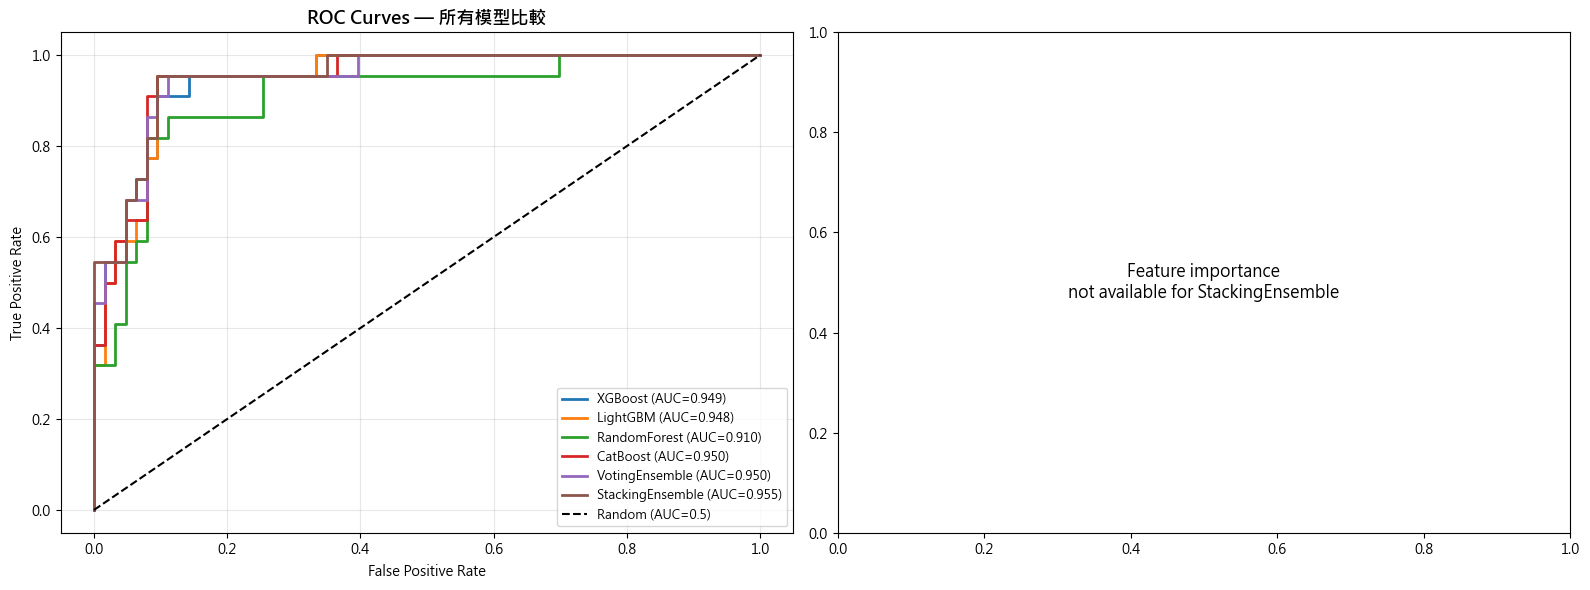

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curves
for name, model in trained_models.items():
    X_v = X_val_imputed.copy()    # ← 原本是 X_val.copy()
    if name == 'CatBoost':
        for col in cat_cols:
            X_v[col] = X_v[col].astype(str)
    prob = model.predict_proba(X_v)[:, 1]
    fpr, tpr, _ = roc_curve(y_val_bin, prob)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

axes[0].plot([0,1],[0,1],'k--', label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — 所有模型比較', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Feature Importance（最佳模型）
if hasattr(best_model, 'feature_importances_'):
    imps = best_model.feature_importances_
    idx  = np.argsort(imps)[-15:]
    axes[1].barh(range(len(idx)), imps[idx], color='steelblue', alpha=0.7)
    axes[1].set_yticks(range(len(idx)))
    axes[1].set_yticklabels([X_proc.columns[i] for i in idx], fontsize=9)
    axes[1].set_title(f'Top 15 特徵重要性 — {best_name}', fontsize=13, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, f'Feature importance\nnot available for {best_name}',
                 ha='center', va='center', fontsize=12, transform=axes[1].transAxes)

plt.tight_layout(); plt.show()


## 9. Stratified 5-Fold 交叉驗證

In [72]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
y_bin_all = (y == 2).astype(int)
cv_results = {}

# 只對不含 CatBoost 的模型做 cross_val_score（CatBoost 需要 cat_features，
# 直接用 cross_val_score 會遺失設定，建議單獨評估）
cv_models = {
    'XGBoost':      make_xgb(),
    'LightGBM':     make_lgb(),
    'RandomForest': make_rf(),
}

for name, model in cv_models.items():
    print(f"{name}:")
    auc_scores = cross_val_score(model, X_proc, y_bin_all,
                                 cv=skf, scoring='roc_auc', n_jobs=-1)
    f1_scores  = cross_val_score(model, X_proc, y_bin_all,
                                 cv=skf, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = {
        'roc_auc_mean': auc_scores.mean(), 'roc_auc_std': auc_scores.std(),
        'f1_macro_mean': f1_scores.mean(), 'f1_macro_std': f1_scores.std()
    }
    print(f"  ROC-AUC: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
    print(f"  F1-Macro: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")

print("\n💡 VotingEnsemble / StackingEnsemble / CatBoost 使用驗證集分數評估")


XGBoost:
  ROC-AUC: 0.9400 ± 0.0499
  F1-Macro: 0.8503 ± 0.0501
LightGBM:
  ROC-AUC: 0.9401 ± 0.0521
  F1-Macro: 0.8479 ± 0.0443
RandomForest:
  ROC-AUC: 0.9234 ± 0.0667
  F1-Macro: 0.8344 ± 0.0527

💡 VotingEnsemble / StackingEnsemble / CatBoost 使用驗證集分數評估


## 10. Optuna 超參數搜尋（XGBoost）

In [73]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def xgb_objective(trial):
        params = {
            'max_depth':        trial.suggest_int('max_depth', 3, 9),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'n_estimators':     trial.suggest_int('n_estimators', 100, 500, step=50),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'scale_pos_weight': scale_pos_weight,
            'random_state': RANDOM_SEED, 'eval_metric': 'auc',
            'tree_method': 'hist', 'enable_categorical': False
        }
        model = xgb.XGBClassifier(**params)
        scores = cross_val_score(model, X_proc, y_bin_all,
                                 cv=skf, scoring='roc_auc', n_jobs=-1)
        return scores.mean()

    print("開始 XGBoost Optuna 搜尋 (n_trials=50)...")
    study_xgb = optuna.create_study(direction='maximize')
    study_xgb.optimize(xgb_objective, n_trials=50)
    print(f"\n最佳參數: {study_xgb.best_params}")
    print(f"最佳 CV ROC-AUC: {study_xgb.best_value:.4f}")

except ImportError:
    print("Optuna 未安裝: pip install optuna")


開始 XGBoost Optuna 搜尋 (n_trials=50)...

最佳參數: {'max_depth': 6, 'learning_rate': 0.027304716799715693, 'n_estimators': 450, 'min_child_weight': 4, 'subsample': 0.7926694127025531, 'colsample_bytree': 0.5904797565565925}
最佳 CV ROC-AUC: 0.9383


## 11. Optuna 超參數搜尋（LightGBM）

In [74]:
try:
    import optuna

    def lgb_objective(trial):
        params = {
            'max_depth':         trial.suggest_int('max_depth', 3, 12),
            'num_leaves':        trial.suggest_int('num_leaves', 10, 100),
            'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'n_estimators':      trial.suggest_int('n_estimators', 100, 600, step=50),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'class_weight': 'balanced',
            'random_state': RANDOM_SEED, 'verbose': -1
        }
        model = lgb.LGBMClassifier(**params)
        scores = cross_val_score(model, X_proc, y_bin_all,
                                 cv=skf, scoring='roc_auc', n_jobs=-1)
        return scores.mean()

    print("開始 LightGBM Optuna 搜尋 (n_trials=50)...")
    study_lgb = optuna.create_study(direction='maximize')
    study_lgb.optimize(lgb_objective, n_trials=50)
    print(f"\n最佳參數: {study_lgb.best_params}")
    print(f"最佳 CV ROC-AUC: {study_lgb.best_value:.4f}")

except ImportError:
    print("Optuna 未安裝: pip install optuna")


開始 LightGBM Optuna 搜尋 (n_trials=50)...

最佳參數: {'max_depth': 11, 'num_leaves': 79, 'learning_rate': 0.0752626641097656, 'n_estimators': 350, 'min_child_samples': 17, 'subsample': 0.7773427422715439, 'colsample_bytree': 0.5160088881768251}
最佳 CV ROC-AUC: 0.9404


## 12. 產生 Kaggle Submission 檔案

In [75]:
# ── 用全部訓練資料重新訓練最終模型 ──────────────────────────────────────
imputer_final = SimpleImputer(strategy='median')
X_all_imputed = pd.DataFrame(
    imputer_final.fit_transform(X_proc),
    columns=X_proc.columns
)
y_bin_all = (y == 2).astype(int)

final_stack_estimators = []
if HAS_XGB: final_stack_estimators.append(('xgb', make_xgb()))
if HAS_LGB: final_stack_estimators.append(('lgb', make_lgb()))
final_stack_estimators.append(('rf', make_rf()))
if HAS_CAT:
    final_stack_estimators.append(('cat', CatBoostClassifier(
        iterations=200, learning_rate=0.05, depth=5,
        auto_class_weights='Balanced', random_seed=RANDOM_SEED, verbose=0
    )))

final_model = StackingClassifier(
    estimators=final_stack_estimators,
    final_estimator=LogisticRegression(C=1.0, max_iter=1000,
                                       class_weight='balanced',
                                       random_state=RANDOM_SEED),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    stack_method='predict_proba',
    n_jobs=-1
)
final_model.fit(X_all_imputed, y_bin_all)
print("✓ 全資料重訓完成")

# ── 測試集前處理 ──────────────────────────────────────────────────────────
X_test_final = clean_df(X_test_proc.copy())
X_test_final = pd.DataFrame(
    imputer_final.transform(X_test_final),   # ← 用 imputer_final，不是舊的 imputer
    columns=X_test_final.columns
)

# ── 預測 ──────────────────────────────────────────────────────────────────
print(f"使用模型: StackingEnsemble（全資料重訓版）")
raw_pred = final_model.predict(X_test_final)

# 模型輸出 0/1，轉回 1(男)/2(女)
test_pred = raw_pred + 1

submission = pd.DataFrame({'id': df_test['id'], 'gender': test_pred})
print(f"Submission gender 分布: {submission['gender'].value_counts().to_dict()}")

SUB_PATH = Path('submission.csv')
submission.to_csv(SUB_PATH, index=False, encoding='utf-8')
print(f"\n✓ 已儲存至 {SUB_PATH}")
print(submission.head(10).to_string(index=False))

✓ 全資料重訓完成
使用模型: StackingEnsemble（全資料重訓版）
Submission gender 分布: {1: 285, 2: 141}

✓ 已儲存至 submission.csv
 id  gender
  1       1
  2       1
  3       2
  4       1
  5       2
  6       1
  7       1
  8       1
  9       1
 10       1


## 13. 總結與實驗建議

### 改善版本完成項目
| 項目 | 狀態 |
|------|------|
| 資料洩漏修正（OrdinalEncoder only fit on train） | ✅ |
| self_intro 文字特徵強化（8 個新特徵） | ✅ |
| sleepiness / yt 異常值標記補齊 | ✅ |
| CatBoost 加入比較 | ✅ |
| VotingEnsemble refitting 問題修正 | ✅ |
| Stacking Ensemble（XGB+LGB+RF+Cat → LR） | ✅ |
| Optuna 搜尋次數提升至 50 trials | ✅ |

### 下一步可嘗試的實驗
1. **`passthrough=True`**：在 StackingClassifier 開啟，讓 meta-learner 同時看原始特徵
2. **Target Encoding**：`star_sign` / `phone_os` 改用 K-Fold target mean encoding
3. **SMOTE**：搭配 `imbalanced-learn` 對少數類過採樣，比較與 class_weight 的差異
4. **Optuna 調參後重訓 Stacking**：把 Optuna 找到的最佳參數套回 stacking 的 base learners